# CNN Autoencoder for Anomaly Detection Using Toy Car Audio

**Purpose:** This notebook presents a complete pipeline for toy car anomaly detection based on operating sound, including data loading, preprocessing, LSTM autoencoder training, and result analysis.

## 1. Imports

This notebook is intentionally split into small orchestration steps. Most reusable logic lives in helper modules so future model notebooks can reuse the same data and evaluation pipeline with minimal copy/paste.

In [ ]:
import os
import random
import glob

import pickle

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Subset, DataLoader

from sklearn.metrics import average_precision_score

import matplotlib.pyplot as plt

import optuna
import optuna.visualization as vis

from helpers.helper_npy_data import (
    UnifiedNPYDataset,
    split_indices,
    compute_target_T_from_npy
)
from helpers.helper_eval import (
    build_scope_loader_dict,
    count_ind_cnt,
    downsample_anomaly_scores,
    evaluate_scores,
    find_best_f1_threshold,
    get_reconstruction_scores,
    infer_case_from_path,
    plot_one_reconstruction,
)

## 2. Paths and configuration

Setting experiment-wide constants here.

In [ ]:
# Paths

DATA_BASE_PATH = "F:ToyCar"

BEST_MODEL_SAVE_PATH = "./outputs/studies/best_LSTM_AE.pth"

STUDY_SAVE_PATH = "./outputs/studies/lstm_study.pkl"

'mv' is not recognized as an internal or external command,
operable program or batch file.
'mv' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
# Configs

CASES = ['case1', 'case2', 'case3', 'case4']
CHANNELS = ['1', '2', '3', '4']
SEED = 42

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

## 3. Data Preprocessing

This stage converts raw/precomputed features into model-ready datasets.

Pipeline summary:
1. Get the timeframe (`target_T`) from IND .npy files, it is needed to detect and remove malformed inputs, and also crop CNT samples (if any) into `target_T` length.
2. Build one unified .npy dataset over IND/CNT/anomaly data (loading the .npy from the 01-data preparation step).
3. Split into train/validation/test partitions.

In [ ]:
# Estimate a robust common length from IND normal data, then build the unified dataset.
target_T = compute_target_T_from_npy(
    base_path=f"{DATA_BASE_PATH}/npy",
    cases=CASES,
)

# Contains all preprocessed .npy 4-channel log-mel spectrogram data
npy_dataset = UnifiedNPYDataset(
    base_path=f"{DATA_BASE_PATH}/npy",
    cases=CASES,
    target_T=target_T,
    use_ind=True,
    use_cnt=True,
    include_anomaly=True,
    stride_ratio=3.0,        # Controls sliding window step size for CNT cropping, if there is CNT data (larger -> fewer overlapping segments)
)

print(f"{len(npy_dataset)} {target_T}")

[INFO] target_T from IND: 582
[INFO] min=582, max=582
[INFO] IND normal: 5400
[INFO] CNT candidates (windows): 15678
[INFO] CNT sampled: 5400
[INFO] IND anomaly: 1058
[WARN] Dropped short samples (< target_T): 1
[INFO] Total samples: 11858
11858 582


## 4. Dataset Splitting and Loader Setup

This section defines how samples are split and sampled.

Important choices:
- Normal data is split separately for IND and CNT, then merged.
- Anomaly samples are held out for validation/test only.
- Case-aware loaders are prepared to measure both per-case and all-case behavior.

In [ ]:
random.seed(42)

# Separate indices
normal_indices = [i for i, (_, _, y) in enumerate(npy_dataset.samples) if y == 0]
anom_indices   = [i for i, (_, _, y) in enumerate(npy_dataset.samples) if y == 1]

# split normal into IND / CNT
ind_indices = [i for i in normal_indices if npy_dataset.samples[i][1] is None]
cnt_indices = [i for i in normal_indices if npy_dataset.samples[i][1] is not None]

random.shuffle(ind_indices)
random.shuffle(cnt_indices)

# Stratified split
ind_train, ind_val, ind_test = split_indices(ind_indices)
cnt_train, cnt_val, cnt_test = split_indices(cnt_indices)

# merge back
train_idx        = ind_train + cnt_train
val_normal_idx   = ind_val + cnt_val
test_normal_idx  = ind_test + cnt_test

# shuffle merged splits
random.shuffle(train_idx)
random.shuffle(val_normal_idx)
random.shuffle(test_normal_idx)

# ANOMALY split (50 / 50)
random.shuffle(anom_indices)

m = len(anom_indices)
val_anom_idx  = anom_indices[:m // 2]
test_anom_idx = anom_indices[m // 2:]

# DATASETS
train_dataset = Subset(npy_dataset, train_idx)

val_normal = Subset(npy_dataset, val_normal_idx)
val_anom   = Subset(npy_dataset, val_anom_idx)

test_normal = Subset(npy_dataset, test_normal_idx)
test_anom   = Subset(npy_dataset, test_anom_idx)

In [ ]:
# Distribution check for IND vs CNT samples in each split
train_ind, train_cnt = count_ind_cnt(train_dataset, npy_dataset.samples)
val_ind, val_cnt = count_ind_cnt(val_normal, npy_dataset.samples)
test_ind, test_cnt = count_ind_cnt(test_normal, npy_dataset.samples)

print("Train Normal  -> IND:", train_ind, "CNT:", train_cnt)
print("Val Normal    -> IND:", val_ind, "CNT:", val_cnt)
print("Test Normal   -> IND:", test_ind, "CNT:", test_cnt)
print("Val/Test anomaly sizes:", len(val_anom), len(test_anom)) # Will be further sampled to 5% below

Train Normal  -> IND: 4320 CNT: 4320
Val Normal    -> IND: 540 CNT: 540
Test Normal   -> IND: 540 CNT: 540
Val/Test anomaly sizes: 529 529


In [ ]:
# -------------------------
# CASE-AWARE LOADERS
# -------------------------
# Map each sample to its case id to enable case-specific evaluation scopes.
sample_cases = [infer_case_from_path(p) for (p, _, _) in npy_dataset.samples]

VAL_CASE_SCOPES = {
    "case1_only": [CASES[0]],
    "case2_only": [CASES[1]],
    "case3_only": [CASES[2]],
    "case4_only": [CASES[3]],
    "all_cases": CASES,
}

# Training loader uses only normal data.
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

val_loaders = build_scope_loader_dict(
    dataset=npy_dataset,
    sample_cases=sample_cases,
    normal_indices=val_normal_idx,
    anom_indices=val_anom_idx,
    case_scopes=VAL_CASE_SCOPES,
    batch_size=8,
    anom_ratio=0.05, 
    prefix="val",
)

for scope_name, data in val_loaders.items():
    print(f"[VAL] {scope_name}: normal={data['n_normal']}, anomaly={data['n_anom']}")

test_loaders = build_scope_loader_dict(
    dataset=npy_dataset,
    sample_cases=sample_cases,
    normal_indices=test_normal_idx,
    anom_indices=test_anom_idx,
    case_scopes=VAL_CASE_SCOPES,
    batch_size=8,
    anom_ratio=0.05, 
    prefix="test",
)

for scope_name, data in test_loaders.items():
    print(f"[TEST] {scope_name}: normal={data['n_normal']}, anomaly={data['n_anom']}")

val_normal_loader = val_loaders["all_cases"]["val_normal_loader"]
val_anom_loader = val_loaders["all_cases"]["val_anom_loader"]
test_normal_loader = test_loaders["all_cases"]["test_normal_loader"]
test_anom_loader = test_loaders["all_cases"]["test_anom_loader"]

[VAL] case1_only: normal=124, anomaly=6
[VAL] case2_only: normal=144, anomaly=7
[VAL] case3_only: normal=145, anomaly=7
[VAL] case4_only: normal=127, anomaly=6
[VAL] all_cases: normal=540, anomaly=27
[TEST] case1_only: normal=145, anomaly=7
[TEST] case2_only: normal=142, anomaly=7
[TEST] case3_only: normal=123, anomaly=6
[TEST] case4_only: normal=130, anomaly=6
[TEST] all_cases: normal=540, anomaly=27


## 5. Model

The architecture is a LSTM AutoEncoder over time dimension of log-mel tensors.


In [ ]:
def to_seq(x):
    """
    Convert a 4D spectrogram tensor into a sequence format suitable for LSTM.

    Input:
        x: Tensor of shape [B, C, M, T]
           B = batch size
           C = number of channels (e.g., 4)
           M = number of mel frequency bins (e.g., 64)
           T = number of time frames (e.g., 582)

    Process:
        1. Permute dimensions to [B, T, C, M]
           - LSTM expects time dimension before features
        2. Flatten channel and frequency into a single feature dimension
           - Final shape becomes [B, T, C*M]

    Returns:
        seq: Tensor of shape [B, T, C*M] (sequence input for LSTM)
        shape: Original shape tuple for reconstruction later
    """
    b, c, m, t = x.shape
    seq = x.permute(0, 3, 1, 2).contiguous().reshape(b, t, c * m)
    return seq, (b, c, m, t)


def from_seq(seq, shape):
    """
    Convert LSTM sequence output back to original spectrogram shape.

    Input:
        seq: Tensor of shape [B, T, C*M]
        shape: Original shape tuple (B, C, M, T)

    Process:
        1. Reshape back to [B, T, C, M]
        2. Permute back to [B, C, M, T]

    Returns:
        Tensor of reconstructed spectrogram with shape [B, C, M, T]
    """
    b, c, m, t = shape
    return seq.reshape(b, t, c, m).permute(0, 2, 3, 1).contiguous()


class LSTMAutoEncoder(nn.Module):
    """
    LSTM-based Autoencoder for multichannel spectrogram reconstruction.

    Architecture:
        Input (spectrogram) → Sequence conversion → Encoder LSTM
        → Latent projection → Decoder LSTM → Output projection → Reconstruction

    Key idea:
        - Compress temporal information into a latent vector
        - Reconstruct the full sequence from this compressed representation
    """

    def __init__(self, input_dim, hidden_dim=256, latent_dim=128, num_layers=2, dropout=0.2):
        """
        Args:
            input_dim: Feature size per time step (C * M)
            hidden_dim: Hidden size of LSTM (controls model capacity)
            latent_dim: Size of bottleneck representation
            num_layers: Number of stacked LSTM layers
            dropout: Dropout applied between LSTM layers
        """
        super().__init__()

        # Encoder
        # Processes input sequence and compresses temporal information
        self.encoder = nn.LSTM(
            input_size=input_dim,              # Feature dimension per timestep
            hidden_size=hidden_dim,            # Hidden state size
            num_layers=num_layers,             # Number of stacked LSTM layers
            dropout=dropout if num_layers > 1 else 0.0,  # Dropout only if >1 layer
            batch_first=True,                  # Input shape: [B, T, F]
        )

        # Map final hidden state to latent space
        self.to_latent = nn.Linear(hidden_dim, latent_dim)

        # Non-linear activation to bound latent space (stabilizes training)
        self.latent_activation = nn.Tanh()

        # Decoder
        # Map latent vector back to hidden dimension
        self.from_latent = nn.Linear(latent_dim, hidden_dim)

        # LSTM decoder reconstructs sequence from repeated latent seed
        self.decoder = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )

        # Final projection back to original feature dimension
        self.output_proj = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        """
        Forward pass of the autoencoder.

        Steps:
        1. Convert spectrogram → sequence
        2. Encode sequence with LSTM
        3. Extract final hidden state as compressed representation
        4. Project to latent space
        5. Expand latent vector across all time steps
        6. Decode sequence using LSTM
        7. Project back to original feature dimension
        8. Reshape back to spectrogram format
        """

        # Step 1: Convert to sequence format
        seq, shape = to_seq(x)   # [B, T, C*M]

        # Step 2: Encode sequence
        _, (h_n, _) = self.encoder(seq)

        # Step 3: Take last layer's hidden state (summary of sequence)
        h_last = h_n[-1]  # shape: [B, hidden_dim]

        # Step 4: Project to latent space
        z = self.latent_activation(self.to_latent(h_last))  # [B, latent_dim]

        # Step 5: Map latent back to decoder hidden dimension
        dec_seed = self.from_latent(z)  # [B, hidden_dim]

        # Step 6: Repeat latent seed across all time steps
        t = seq.size(1)
        dec_in = dec_seed.unsqueeze(1).repeat(1, t, 1)  # [B, T, hidden_dim]

        # Step 7: Decode sequence
        dec_out, _ = self.decoder(dec_in)

        # Step 8: Project to original feature dimension
        recon_seq = self.output_proj(dec_out)  # [B, T, input_dim]

        # Step 9: Convert back to spectrogram format
        recon = from_seq(recon_seq, shape)  # [B, C, M, T]

        return recon


def reconstruction_errors(model, loader):
    """
    Compute reconstruction error (anomaly score) for each sample.

    Process:
        - Pass input through autoencoder
        - Compute reconstruction error (L1 distance)
        - Average over all dimensions per sample

    Args:
        model: Trained autoencoder
        loader: DataLoader providing (input, label) pairs

    Returns:
        scores: numpy array of reconstruction errors per sample
                (higher = more anomalous)
    """
    model.eval()  # Set model to evaluation mode (disable dropout, etc.)
    scores = []

    with torch.no_grad():  # Disable gradient computation for efficiency
        for x, _ in loader:
            x = x.to(device)

            # Forward pass
            recon = model(x)

            # Compute L1 reconstruction error per sample
            # Averaged over channels, frequency bins, and time
            err = torch.mean(torch.abs(x - recon), dim=(1, 2, 3))

            # Move to CPU and store
            scores.extend(err.detach().cpu().numpy())

    return np.array(scores)

[INFO] device: cuda


## 6. Fine Tuning

Optuna searches model and training hyperparameters.

Each trial trains a candidate model and reports validation PR-AUC on the selected tuning scope.

In [ ]:
from torch.utils.data import DataLoader
import optuna
TUNE_SCOPE = "all_cases"
N_TRIALS = 30
TUNE_EPOCHS = 30

def objective(trial):
    hidden_dim = trial.suggest_categorical("hidden_dim", [128, 192, 256, 320])
    latent_dim = trial.suggest_categorical("latent_dim", [64, 96, 128, 160])
    num_layers = trial.suggest_int("num_layers", 1, 3)
    dropout = trial.suggest_float("dropout", 0.0, 0.4)
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-7, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    loss_type = trial.suggest_categorical("loss_type", ["l1", "l2"])

    train_loader_tune = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    vn_loader_local = val_normal_loader
    va_loader_local = val_anom_loader

    x0, _ = next(iter(train_loader_tune))
    _, c, m, _ = x0.shape
    input_dim = c * m

    model = LSTMAutoEncoder(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        latent_dim=latent_dim,
        num_layers=num_layers,
        dropout=dropout,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.L1Loss() if loss_type == "l1" else nn.MSELoss()

    for _ in range(TUNE_EPOCHS):
        model.train()
        for x, _ in train_loader_tune:
            x = x.to(device)
            recon = model(x)
            loss = criterion(recon, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    normal_scores = reconstruction_errors(model, vn_loader_local)
    anom_scores = reconstruction_errors(model, va_loader_local)

    y_true = np.concatenate([np.zeros(len(normal_scores)), np.ones(len(anom_scores))])
    y_score = np.concatenate([normal_scores, anom_scores])

    if len(np.unique(y_true)) < 2:
        return 0.0

    pr_auc = average_precision_score(y_true, y_score)
    gap = float(np.mean(anom_scores) - np.mean(normal_scores))
    trial.set_user_attr("gap", gap)
    trial.set_user_attr("pr_auc", float(pr_auc))
    trial.set_user_attr("loss_type", loss_type)
    return float(pr_auc)

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=N_TRIALS)
print("[BEST] PR-AUC:", study.best_value)
print("[BEST] params:", study.best_params)

best_params = study.best_params.copy()

In [ ]:
# Save study into Pickle .pkl file
with open(STUDY_SAVE_PATH, "wb") as f:
    pickle.dump(study, f)

## 7. Training the model using the optimal hyperparams

In [ ]:
# Rebuild model with best params

best_params = {
    "hidden_dim": 256,
    "latent_dim": 96,
    "num_layers": 2,
    "dropout": 0.17513596367181428,
    "lr": 0.0006420218819346047,
    "weight_decay": 4.121506603185355e-07,
    "batch_size": 8,
    "loss_type": "l1",
}

# Optional: reload study from .pkl
# with open(STUDY_SAVE_PATH, 'rb') as f:
#     study = pickle.load(f)

hidden_dim = best_params["hidden_dim"]
latent_dim = best_params["latent_dim"]
num_layers = best_params["num_layers"]
dropout = best_params["dropout"]

sample_x, _ = next(iter(train_loader))
_, c, m, _ = sample_x.shape
input_dim = c * m

model = LSTMAutoEncoder(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    latent_dim=latent_dim,
    num_layers=num_layers,
    dropout=dropout,
).to(device)

In [ ]:
FINAL_EPOCHS = 50

best = best_params.copy()
batch_size = best["batch_size"]
loss_type = best["loss_type"]

train_loader_final = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
x0, _ = next(iter(train_loader_final))
_, c, m, _ = x0.shape
input_dim = c * m

best_model = LSTMAutoEncoder(
    input_dim=input_dim,
    hidden_dim=best["hidden_dim"],
    latent_dim=best["latent_dim"],
    num_layers=best["num_layers"],
    dropout=best["dropout"],
).to(device)

optimizer = torch.optim.AdamW(
    best_model.parameters(),
    lr=best["lr"],
    weight_decay=best["weight_decay"],
)
criterion = nn.L1Loss() if loss_type == "l1" else nn.MSELoss()
print(f"[INFO] Final loss: {loss_type.upper()}")

# Track both curves for plotting
train_loss_hist = []
val_loss_hist = []

for epoch in range(FINAL_EPOCHS):
    best_model.train()
    total_train_loss = 0.0
    for x, _ in train_loader_final:
        x = x.to(device)
        recon = best_model(x)
        loss = criterion(recon, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader_final)
    train_loss_hist.append(avg_train_loss)

    # Validation loss (normal validation set)
    best_model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for x, _ in val_normal_loader:
            x = x.to(device)
            recon = best_model(x)
            total_val_loss += criterion(recon, x).item()

    avg_val_loss = total_val_loss / len(val_normal_loader)
    val_loss_hist.append(avg_val_loss)

    print(f"[FINAL TRAIN] epoch={epoch+1}/{FINAL_EPOCHS} train={avg_train_loss:.6f} val={avg_val_loss:.6f}")

def eval_current_loaders(model):
    normal_scores = reconstruction_errors(model, test_normal_loader)
    anom_scores = reconstruction_errors(model, test_anom_loader)

    y_true = np.concatenate([np.zeros(len(normal_scores)), np.ones(len(anom_scores))])
    y_score = np.concatenate([normal_scores, anom_scores])

    pr_auc = average_precision_score(y_true, y_score) if len(np.unique(y_true)) == 2 else float("nan")
    gap = float(np.mean(anom_scores) - np.mean(normal_scores))
    threshold = float(np.percentile(normal_scores, 95)) if len(normal_scores) > 0 else float("nan")
    recall = float(np.mean(anom_scores > threshold)) if len(anom_scores) > 0 and not np.isnan(threshold) else float("nan")

    return {
        "n_normal": len(normal_scores),
        "n_anom": len(anom_scores),
        "pr_auc": pr_auc,
        "gap": gap,
        "threshold95": threshold,
        "anom_recall": recall,
    }

result = eval_current_loaders(best_model)
print(
    f"[TEST] n_normal={result['n_normal']} n_anom={result['n_anom']} "
    f"PR-AUC={result['pr_auc']:.4f} GAP={result['gap']:.6f} "
    f"THR95={result['threshold95']:.6f} RECALL={result['anom_recall']:.4f}"
)

[INFO] Final loss: L1
[FINAL TRAIN] epoch=1/50 train=0.062802 val=0.055227
[FINAL TRAIN] epoch=2/50 train=0.047904 val=0.047842
[FINAL TRAIN] epoch=3/50 train=0.044348 val=0.046785
[FINAL TRAIN] epoch=4/50 train=0.042498 val=0.043428
[FINAL TRAIN] epoch=5/50 train=0.041477 val=0.040810
[FINAL TRAIN] epoch=6/50 train=0.041241 val=0.041347
[FINAL TRAIN] epoch=7/50 train=0.040423 val=0.039298
[FINAL TRAIN] epoch=8/50 train=0.039087 val=0.039168
[FINAL TRAIN] epoch=9/50 train=0.038330 val=0.038918
[FINAL TRAIN] epoch=10/50 train=0.037705 val=0.039211
[FINAL TRAIN] epoch=11/50 train=0.037771 val=0.039683
[FINAL TRAIN] epoch=12/50 train=0.037596 val=0.038839
[FINAL TRAIN] epoch=13/50 train=0.037250 val=0.039842
[FINAL TRAIN] epoch=14/50 train=0.037288 val=0.039724
[FINAL TRAIN] epoch=15/50 train=0.037534 val=0.038485
[FINAL TRAIN] epoch=16/50 train=0.037062 val=0.038753
[FINAL TRAIN] epoch=17/50 train=0.036925 val=0.038681
[FINAL TRAIN] epoch=18/50 train=0.037177 val=0.038609
[FINAL TRAIN] e

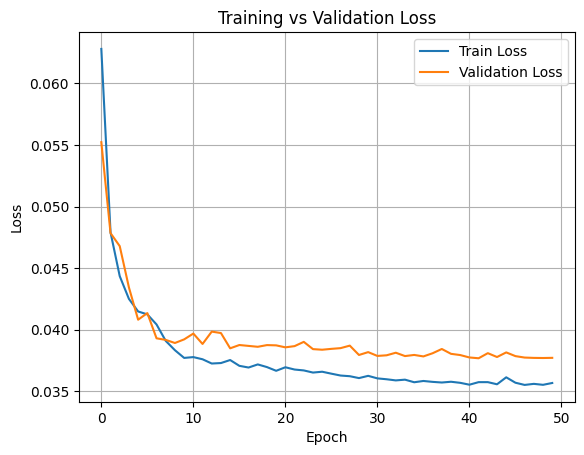

In [13]:
import matplotlib.pyplot as plt

if "train_loss_hist" not in globals() or "val_loss_hist" not in globals():
    print("Run Cell 8 first to generate train_loss_hist and val_loss_hist.")
else:
    plt.figure()
    plt.plot(train_loss_hist, label="Train Loss")
    plt.plot(val_loss_hist, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid()
    plt.show()

## 8. Model Evaluation

Evaluation is performed in two steps:
1. Find a threshold on validation scores (best F1).
2. Report PR-AUC/F1/gap on overall and per-case test sets.

In [ ]:
# Optional: Load saved model

# with open(STUDY_SAVE_PATH, 'rb') as f:
#     study = pickle.load(f)

# hidden_dim = best_params["hidden_dim"]
# latent_dim = best_params["latent_dim"]
# num_layers = best_params["num_layers"]
# dropout = best_params["dropout"]

# sample_x, _ = next(iter(train_loader))
# _, c, m, _ = sample_x.shape
# input_dim = c * m

# model = LSTMAutoEncoder(
#     input_dim=input_dim,
#     hidden_dim=hidden_dim,
#     latent_dim=latent_dim,
#     num_layers=num_layers,
#     dropout=dropout,
# ).to(device)
# model.load_state_dict(torch.load(BEST_MODEL_SAVE_PATH, map_location=device))
# model.eval()

In [ ]:
# Compute validation threshold by maximizing F1 on validation scores.
# This converts continuous anomaly scores into a binary decision boundary.
val_normal_scores = get_reconstruction_scores(
    model,
    val_normal_loader,
    device,
    score_type=best_params["score_type"],
)
val_anom_scores = get_reconstruction_scores(
    model,
    val_anom_loader,
    device,
    score_type=best_params["score_type"],
)

best_threshold = find_best_f1_threshold(val_normal_scores, val_anom_scores)
print("Best threshold:", best_threshold)

Best threshold: 0.04237468


In [ ]:
# Evaluate on the overall test scope (`all_cases`).
# Keep anomaly ratio aligned with validation for fair comparison.
test_normal_scores = get_reconstruction_scores(
    model,
    test_normal_loader,
    device,
    score_type=best_params["score_type"],
)
test_anom_scores = get_reconstruction_scores(
    model,
    test_anom_loader,
    device,
    score_type=best_params["score_type"],
)

pr_auc, f1, gap = evaluate_scores(test_normal_scores, test_anom_scores, best_threshold)

print("Best threshold:", best_threshold)
print("Test PR-AUC:", pr_auc)
print("Test F1:", f1)
print("Normal Mean Error:", float(np.mean(test_normal_scores)))
print("Anomalous Mean Error:", float(np.mean(test_anom_scores)))
print("Error Gap:", gap)

Best threshold: 0.04242218
Test PR-AUC: 0.83472195
Test F1: 0.83216883
Normal Mean Error: 0.034845782
Anomalous Mean Error: 0.04562167


In [ ]:
# Per-case test results highlight whether performance is consistent across cases.
print("\n=== Per-case Test Results ===")

all_normal_scores = []
all_anom_scores = []

for scope_name, loaders in test_loaders.items():
    normal_scores = get_reconstruction_scores(
        model,
        loaders["test_normal_loader"],
        device,
        score_type=best_params["score_type"],
    )
    anom_scores = get_reconstruction_scores(
        model,
        loaders["test_anom_loader"],
        device,
        score_type=best_params["score_type"],
    )

    # Use full anomaly set per case for stable per-case reporting.
    anom_scores = downsample_anomaly_scores(normal_scores, anom_scores, anom_ratio=1.0)

    if scope_name != "all_cases":
        all_normal_scores.extend(normal_scores)
        all_anom_scores.extend(anom_scores)

    pr_auc, f1, gap = evaluate_scores(normal_scores, anom_scores, best_threshold)
    print(f"{scope_name}: PR-AUC={pr_auc:.4f}, F1={f1:.4f}, Gap={gap:.4f}")


=== Per-case Test Results ===
(145,) (7,)
case1_only: PR-AUC=0.9071, F1=0.9231, Gap=0.0094
(142,) (7,)
case2_only: PR-AUC=0.9821, F1=0.7273, Gap=0.0084
(123,) (6,)
case3_only: PR-AUC=1.0000, F1=0.7059, Gap=0.0103
(130,) (6,)
case4_only: PR-AUC=1.0000, F1=1.0000, Gap=0.0192
(540,) (27,)
all_cases: PR-AUC=0.9447, F1=0.8571, Gap=0.0108
